In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Project paths
PROJECT_DIR = Path("..")  # Assuming the notebook is inside /notebooks
DATA_DIR = PROJECT_DIR / "data"
SYNTHETIC_DIR = DATA_DIR / "synthetic"
FIGURES_DIR = PROJECT_DIR / "figures" / "01_dataset_generation"

SYNTHETIC_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Synthetic data directory:", SYNTHETIC_DIR.resolve())
print("Figures directory:", FIGURES_DIR.resolve())

Synthetic data directory: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\data\synthetic
Figures directory: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\figures\01_dataset_generation


In [2]:
# Number of synthetic acquisitions
N = 1000

# Each row represents one simulated microCT acquisition / analyzed subvolume
sample_id = np.arange(1, N + 1)
time_index = np.arange(N)

# Experimental batches
n_batches = 20
batch_id = rng.integers(1, n_batches + 1, size=N)

# A/B protocols
# A: standard acquisition
# B: optimized acquisition
protocol = rng.choice(["A_standard", "B_optimized"], size=N, p=[0.5, 0.5])

df = pd.DataFrame({
    "sample_id": sample_id,
    "time_index": time_index,
    "batch_id": batch_id,
    "protocol": protocol
})

df.head()

,sample_id,time_index,batch_id,protocol
0,1,0,2,B_optimized
1,2,1,16,B_optimized
2,3,2,14,B_optimized
3,4,3,9,B_optimized
4,5,4,9,B_optimized


In [3]:
def generate_by_protocol(protocol_array, mean_a, std_a, mean_b, std_b, min_value=None, max_value=None):
    """
    Generate values depending on acquisition protocol.
    Protocol A and B are sampled from different normal distributions.
    """
    values = np.empty(len(protocol_array), dtype=float)

    mask_a = protocol_array == "A_standard"
    mask_b = protocol_array == "B_optimized"

    values[mask_a] = rng.normal(mean_a, std_a, mask_a.sum())
    values[mask_b] = rng.normal(mean_b, std_b, mask_b.sum())

    if min_value is not None:
        values = np.maximum(values, min_value)
    if max_value is not None:
        values = np.minimum(values, max_value)

    return values


# Acquisition parameters
df["voltage_kV"] = generate_by_protocol(
    df["protocol"].values,
    mean_a=130, std_a=8,
    mean_b=135, std_b=6,
    min_value=100, max_value=160
)

df["current_uA"] = generate_by_protocol(
    df["protocol"].values,
    mean_a=70, std_a=8,
    mean_b=80, std_b=8,
    min_value=40, max_value=120
)

df["exposure_ms"] = generate_by_protocol(
    df["protocol"].values,
    mean_a=350, std_a=70,
    mean_b=650, std_b=90,
    min_value=100, max_value=1000
)

df["n_projections"] = generate_by_protocol(
    df["protocol"].values,
    mean_a=900, std_a=120,
    mean_b=1600, std_b=180,
    min_value=400, max_value=2200
).round().astype(int)

df["voxel_size_um"] = generate_by_protocol(
    df["protocol"].values,
    mean_a=80, std_a=10,
    mean_b=55, std_b=8,
    min_value=35, max_value=110
)

df["filter_thickness_mm"] = generate_by_protocol(
    df["protocol"].values,
    mean_a=0.5, std_a=0.15,
    mean_b=0.8, std_b=0.20,
    min_value=0.1, max_value=1.5
)

df.head()

,sample_id,time_index,batch_id,protocol,voltage_kV,current_uA,exposure_ms,n_projections,voxel_size_um,filter_thickness_mm
0,1,0,2,B_optimized,139.779264,79.740205,556.875111,1661,67.210426,1.017422
1,2,1,16,B_optimized,133.584995,88.224429,509.266539,1568,58.500142,0.841840
2,3,2,14,B_optimized,133.159816,79.573577,669.746240,1346,56.410341,1.085016
3,4,3,9,B_optimized,135.628140,79.754049,671.113602,1778,53.400963,0.566273
4,5,4,9,B_optimized,145.179520,75.327765,803.071348,1107,54.595544,0.742277


In [4]:
# True material / sample properties
# Porosity between roughly 2% and 18%
df["true_porosity"] = rng.beta(a=2.5, b=12, size=N) * 0.30
df["true_porosity"] = df["true_porosity"].clip(0.01, 0.22)

# Mean pore diameter in micrometers
df["true_mean_pore_diameter_um"] = rng.lognormal(
    mean=np.log(220),
    sigma=0.45,
    size=N
)
df["true_mean_pore_diameter_um"] = df["true_mean_pore_diameter_um"].clip(40, 900)

# Heterogeneity index: 0 = homogeneous, 1 = highly heterogeneous
df["true_heterogeneity"] = rng.beta(a=2, b=5, size=N)

# Effective sample thickness in mm
df["sample_thickness_mm"] = rng.normal(loc=8.0, scale=1.0, size=N).clip(5.0, 12.0)

df[[
    "true_porosity",
    "true_mean_pore_diameter_um",
    "true_heterogeneity",
    "sample_thickness_mm"
]].describe()

,true_porosity,true_mean_pore_diameter_um,true_heterogeneity,sample_thickness_mm
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.050259,238.793192,0.279914,8.073335
std,0.027832,112.413468,0.157416,1.019434
min,0.010000,57.693686,0.012455,5.000000
25%,0.028565,162.712731,0.158372,7.418145
50%,0.045832,218.469067,0.265318,8.065395
75%,0.066653,283.813216,0.374307,8.739702
max,0.149802,900.000000,0.878343,11.157756


In [5]:
# ------------------------------------------------------------
# Physics-informed signal model
# ------------------------------------------------------------

# Simplified attenuation coefficients.
# These values are not intended to represent a specific material exactly.
# They are chosen to generate realistic synthetic trends.
mu_matrix_base = 0.22  # effective attenuation coefficient of solid matrix
mu_pore = 0.02         # pores / air-like phase

# Higher voltage generally reduces effective attenuation contrast.
# We model this with a mild inverse dependence on voltage.
voltage_ref = 130
df["mu_matrix_effective"] = mu_matrix_base * (voltage_ref / df["voltage_kV"]) ** 0.7

# Beer-Lambert transmitted intensities
df["intensity_matrix"] = np.exp(
    -df["mu_matrix_effective"] * df["sample_thickness_mm"]
)

df["intensity_pore"] = np.exp(
    -mu_pore * df["sample_thickness_mm"]
)

# Attenuation contrast between matrix and pores
df["attenuation_contrast"] = np.abs(
    df["intensity_pore"] - df["intensity_matrix"]
)

# Photon / count-like signal proxy
# Signal increases with current, exposure, and number of projections.
df["photon_signal"] = (
    df["current_uA"]
    * df["exposure_ms"]
    * df["n_projections"]
)

# Normalize signal to avoid very large numbers
df["photon_signal_norm"] = df["photon_signal"] / df["photon_signal"].median()

# Relative counting noise: proportional to 1 / sqrt(signal)
base_noise = 0.08
df["relative_noise"] = base_noise / np.sqrt(df["photon_signal_norm"])

# Add a small random experimental component
df["relative_noise"] += rng.normal(0, 0.005, size=N)
df["relative_noise"] = df["relative_noise"].clip(0.005, None)

# Signal-to-noise ratio and contrast-to-noise ratio
df["snr"] = df["intensity_matrix"] / df["relative_noise"]
df["cnr"] = df["attenuation_contrast"] / df["relative_noise"]

df[[
    "mu_matrix_effective",
    "attenuation_contrast",
    "photon_signal_norm",
    "relative_noise",
    "snr",
    "cnr"
]].describe()

,mu_matrix_effective,attenuation_contrast,photon_signal_norm,relative_noise,snr,cnr
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.218417,0.674743,1.364135,0.082476,2.472297,9.315656
std,0.009320,0.026233,0.869180,0.029642,1.142649,3.310768
min,0.196009,0.568192,0.227559,0.029856,0.501759,3.798672
25%,0.211823,0.659890,0.550574,0.054915,1.534087,6.265081
50%,0.217357,0.677980,1.000000,0.078141,2.270347,8.662521
75%,0.223922,0.692737,2.151239,0.108543,3.223014,12.073840
max,0.254427,0.733580,4.062246,0.164464,7.210905,22.998669


In [7]:
# Detectability ratio
# Larger values mean pores are better resolved by the voxel size.
df["pore_detectability"] = (
    df["true_mean_pore_diameter_um"] / df["voxel_size_um"]
)

# A bounded detectability score between 0 and 1
# The sigmoid-like function makes detectability improve smoothly.
df["detectability_score"] = 1 / (
    1 + np.exp(-(df["pore_detectability"] - 3.0))
)

df[[
    "voxel_size_um",
    "true_mean_pore_diameter_um",
    "pore_detectability",
    "detectability_score"
]].describe()

,voxel_size_um,true_mean_pore_diameter_um,pore_detectability,detectability_score
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,68.258157,238.793192,3.709467,0.576209
std,15.801982,112.413468,2.019886,0.271894
min,35.000000,57.693686,0.990539,0.118213
25%,54.753607,162.712731,2.319388,0.336125
50%,67.397025,218.469067,3.269874,0.567062
75%,81.537086,283.813216,4.602076,0.832308
max,110.000000,900.000000,17.142226,0.999999


In [8]:
# ------------------------------------------------------------
# Segmentation error model
# ------------------------------------------------------------

# Error components
cnr_error_component = 0.035 / (df["cnr"] + 0.5)
resolution_error_component = 0.025 * (1 - df["detectability_score"])
heterogeneity_error_component = 0.020 * df["true_heterogeneity"]
noise_error_component = 0.20 * df["relative_noise"]

# Random measurement error
random_error = rng.normal(0, 0.006, size=N)

# Total absolute-like segmentation error
df["segmentation_abs_error"] = (
    cnr_error_component
    + resolution_error_component
    + heterogeneity_error_component
    + noise_error_component
    + np.abs(random_error)
)

# Segmentation bias:
# For poor detectability, porosity tends to be underestimated.
# For high noise, false positives can overestimate porosity.
undersegmentation_bias = -0.030 * (1 - df["detectability_score"])
false_positive_bias = 0.080 * df["relative_noise"]

df["segmentation_bias"] = (
    undersegmentation_bias
    + false_positive_bias
    + rng.normal(0, 0.004, size=N)
)

# Estimated porosity
df["estimated_porosity"] = (
    df["true_porosity"]
    + df["segmentation_bias"]
    + rng.normal(0, df["segmentation_abs_error"] / 3, size=N)
)

df["estimated_porosity"] = df["estimated_porosity"].clip(0, 0.35)

# Signed and absolute porosity error
df["porosity_error"] = df["estimated_porosity"] - df["true_porosity"]
df["abs_porosity_error"] = np.abs(df["porosity_error"])

# Estimated mean pore diameter
# Low detectability tends to underestimate pore size.
df["estimated_mean_pore_diameter_um"] = (
    df["true_mean_pore_diameter_um"]
    * (0.90 + 0.10 * df["detectability_score"])
    + rng.normal(0, 25, size=N)
)

df["estimated_mean_pore_diameter_um"] = df["estimated_mean_pore_diameter_um"].clip(10, None)

df[[
    "true_porosity",
    "estimated_porosity",
    "porosity_error",
    "abs_porosity_error",
    "true_mean_pore_diameter_um",
    "estimated_mean_pore_diameter_um"
]].describe()

,true_porosity,estimated_porosity,porosity_error,abs_porosity_error,true_mean_pore_diameter_um,estimated_mean_pore_diameter_um
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.050259,0.045019,-0.005240,0.012802,238.793192,231.080063
std,0.027832,0.030781,0.015538,0.010240,112.413468,116.581361
min,0.010000,0.000000,-0.061775,0.000009,57.693686,39.884806
25%,0.028565,0.021054,-0.014443,0.005131,162.712731,152.100595
50%,0.045832,0.041985,-0.004653,0.010449,218.469067,206.485908
75%,0.066653,0.063482,0.005526,0.017562,283.813216,281.590425
max,0.149802,0.148555,0.041082,0.061775,900.000000,873.821462


In [9]:
# ------------------------------------------------------------
# Temporal drift
# ------------------------------------------------------------

# Smooth detector drift across acquisition time
# Positive values increase noise slowly with time.
drift_strength = 0.00025
df["detector_drift"] = 1 + drift_strength * df["time_index"]

# Apply drift to noise-related quantities
df["relative_noise_drifted"] = df["relative_noise"] * df["detector_drift"]

# Recompute SNR and CNR with drift
df["snr_drifted"] = df["intensity_matrix"] / df["relative_noise_drifted"]
df["cnr_drifted"] = df["attenuation_contrast"] / df["relative_noise_drifted"]

# Experimental outliers
# These represent failed acquisitions, motion artifacts, reconstruction issues, etc.
outlier_fraction = 0.04
n_outliers = int(N * outlier_fraction)

outlier_indices = rng.choice(df.index, size=n_outliers, replace=False)
df["is_outlier"] = False
df.loc[outlier_indices, "is_outlier"] = True

# Outliers have worse noise and higher errors
df.loc[outlier_indices, "relative_noise_drifted"] *= rng.uniform(1.8, 3.0, size=n_outliers)
df.loc[outlier_indices, "snr_drifted"] = (
    df.loc[outlier_indices, "intensity_matrix"]
    / df.loc[outlier_indices, "relative_noise_drifted"]
)
df.loc[outlier_indices, "cnr_drifted"] = (
    df.loc[outlier_indices, "attenuation_contrast"]
    / df.loc[outlier_indices, "relative_noise_drifted"]
)

df.loc[outlier_indices, "estimated_porosity"] += rng.normal(0, 0.04, size=n_outliers)
df["estimated_porosity"] = df["estimated_porosity"].clip(0, 0.35)

df["porosity_error"] = df["estimated_porosity"] - df["true_porosity"]
df["abs_porosity_error"] = np.abs(df["porosity_error"])

df["is_outlier"].value_counts()

is_outlier
False    960
True      40
Name: count, dtype: int64

In [10]:
# ------------------------------------------------------------
# Synthetic quality score
# ------------------------------------------------------------

# Normalize useful variables
snr_norm = (df["snr_drifted"] - df["snr_drifted"].min()) / (
    df["snr_drifted"].max() - df["snr_drifted"].min()
)

cnr_norm = (df["cnr_drifted"] - df["cnr_drifted"].min()) / (
    df["cnr_drifted"].max() - df["cnr_drifted"].min()
)

error_norm = (df["abs_porosity_error"] - df["abs_porosity_error"].min()) / (
    df["abs_porosity_error"].max() - df["abs_porosity_error"].min()
)

# Quality score between 0 and 100
df["quality_score"] = (
    100
    * (
        0.35 * snr_norm
        + 0.35 * cnr_norm
        + 0.20 * df["detectability_score"]
        + 0.10 * (1 - error_norm)
    )
)

# Penalize outliers
df.loc[df["is_outlier"], "quality_score"] *= 0.65

df["quality_score"] = df["quality_score"].clip(0, 100)

df[[
    "protocol",
    "snr_drifted",
    "cnr_drifted",
    "abs_porosity_error",
    "quality_score",
    "is_outlier"
]].describe()

,snr_drifted,cnr_drifted,abs_porosity_error,quality_score
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.151279,8.118515,0.013261,42.151922
std,1.038519,3.113532,0.011009,15.074354
min,0.350592,1.952028,0.000009,5.264957
25%,1.313386,5.430811,0.005248,29.515649
50%,1.934063,7.280801,0.010635,40.795884
75%,2.865181,10.762045,0.017879,54.912264
max,6.085152,20.752239,0.089741,87.825861


In [11]:
columns_order = [
    # Identification
    "sample_id",
    "time_index",
    "batch_id",
    "protocol",
    "is_outlier",

    # Acquisition parameters
    "voltage_kV",
    "current_uA",
    "exposure_ms",
    "n_projections",
    "voxel_size_um",
    "filter_thickness_mm",

    # True sample properties
    "true_porosity",
    "true_mean_pore_diameter_um",
    "true_heterogeneity",
    "sample_thickness_mm",

    # Physics-informed variables
    "mu_matrix_effective",
    "intensity_matrix",
    "intensity_pore",
    "attenuation_contrast",
    "photon_signal",
    "photon_signal_norm",
    "relative_noise",
    "detector_drift",
    "relative_noise_drifted",
    "snr",
    "cnr",
    "snr_drifted",
    "cnr_drifted",

    # Resolution / detectability
    "pore_detectability",
    "detectability_score",

    # Segmentation outputs
    "segmentation_bias",
    "segmentation_abs_error",
    "estimated_porosity",
    "porosity_error",
    "abs_porosity_error",
    "estimated_mean_pore_diameter_um",

    # Final synthetic metric
    "quality_score"
]

df = df[columns_order]

df.head()

,sample_id,time_index,batch_id,protocol,is_outlier,voltage_kV,current_uA,exposure_ms,n_projections,voxel_size_um,...,cnr_drifted,pore_detectability,detectability_score,segmentation_bias,segmentation_abs_error,estimated_porosity,porosity_error,abs_porosity_error,estimated_mean_pore_diameter_um,quality_score
0,1,0,2,B_optimized,False,139.779264,79.740205,556.875111,1661,67.210426,...,11.970542,4.498315,0.817323,0.002659,0.027658,0.030204,-0.014338,0.014338,286.139470,62.765687
1,2,1,16,B_optimized,False,133.584995,88.224429,509.266539,1568,58.500142,...,11.447199,2.712877,0.428708,-0.013057,0.036648,0.029836,-0.025635,0.025635,159.526529,60.292433
2,3,2,14,B_optimized,False,133.159816,79.573577,669.746240,1346,56.410341,...,13.206688,1.589025,0.196080,-0.017634,0.050556,0.036438,-0.012289,0.012289,78.196105,53.693052
3,4,3,9,B_optimized,False,135.628140,79.754049,671.113602,1778,53.400963,...,13.997532,3.189257,0.547174,-0.019351,0.034133,0.007531,-0.015526,0.015526,140.557286,64.812592
4,5,4,9,B_optimized,False,145.179520,75.327765,803.071348,1107,54.595544,...,9.636927,10.265431,0.999301,0.004142,0.023105,0.048718,0.001730,0.001730,543.656069,64.667183


In [12]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))

print("\nProtocol counts:")
print(df["protocol"].value_counts())

print("\nOutlier counts:")
print(df["is_outlier"].value_counts())

df.describe().T.head(20)

Dataset shape: (1000, 37)

Missing values:
sample_id        0
time_index       0
batch_id         0
protocol         0
is_outlier       0
voltage_kV       0
current_uA       0
exposure_ms      0
n_projections    0
voxel_size_um    0
dtype: int64

Protocol counts:
protocol
A_standard     509
B_optimized    491
Name: count, dtype: int64

Outlier counts:
is_outlier
False    960
True      40
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
sample_id,1000.0,5.005000e+02,2.888194e+02,1.000000e+00,2.507500e+02,5.005000e+02,7.502500e+02,1.000000e+03
time_index,1000.0,4.995000e+02,2.888194e+02,0.000000e+00,2.497500e+02,4.995000e+02,7.492500e+02,9.990000e+02
batch_id,1000.0,1.054500e+01,5.772113e+00,1.000000e+00,5.000000e+00,1.100000e+01,1.600000e+01,2.000000e+01
voltage_kV,1000.0,1.317540e+02,7.846105e+00,1.056189e+02,1.267597e+02,1.322638e+02,1.372282e+02,1.533140e+02
current_uA,1000.0,7.520917e+01,9.303714e+00,4.710785e+01,6.904818e+01,7.540634e+01,8.158083e+01,1.047081e+02
exposure_ms,1000.0,4.971223e+02,1.696382e+02,1.662397e+02,3.464648e+02,4.691683e+02,6.453578e+02,9.608642e+02
n_projections,1000.0,1.243231e+03,3.861009e+02,5.230000e+02,8.950000e+02,1.132500e+03,1.601000e+03,2.183000e+03
voxel_size_um,1000.0,6.825816e+01,1.580198e+01,3.500000e+01,5.475361e+01,6.739703e+01,8.153709e+01,1.100000e+02
filter_thickness_mm,1000.0,6.461798e-01,2.294013e-01,1.000000e-01,4.712808e-01,6.281095e-01,8.037669e-01,1.458771e+00
true_porosity,1000.0,5.025912e-02,2.783164e-02,1.000000e-02,2.856503e-02,4.583244e-02,6.665269e-02,1.498024e-01


In [13]:
protocol_summary = (
    df
    .groupby("protocol")
    .agg(
        n=("sample_id", "count"),
        mean_exposure_ms=("exposure_ms", "mean"),
        mean_n_projections=("n_projections", "mean"),
        mean_voxel_size_um=("voxel_size_um", "mean"),
        mean_snr=("snr_drifted", "mean"),
        mean_cnr=("cnr_drifted", "mean"),
        mean_abs_porosity_error=("abs_porosity_error", "mean"),
        mean_quality_score=("quality_score", "mean"),
    )
    .round(3)
)

protocol_summary

,n,mean_exposure_ms,mean_n_projections,mean_voxel_size_um,mean_snr,mean_cnr,mean_abs_porosity_error,mean_quality_score
protocol,,,,,,,,
A_standard,509,350.009,895.000,80.745,1.402,5.592,0.014,30.854
B_optimized,491,649.628,1604.228,55.314,2.928,10.737,0.012,53.864


Saved: ..\figures\01_dataset_generation\true_porosity_distribution.png


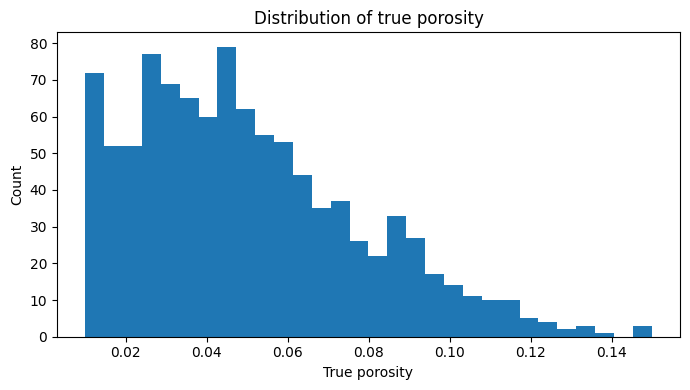

Saved: ..\figures\01_dataset_generation\relative_noise_vs_exposure.png


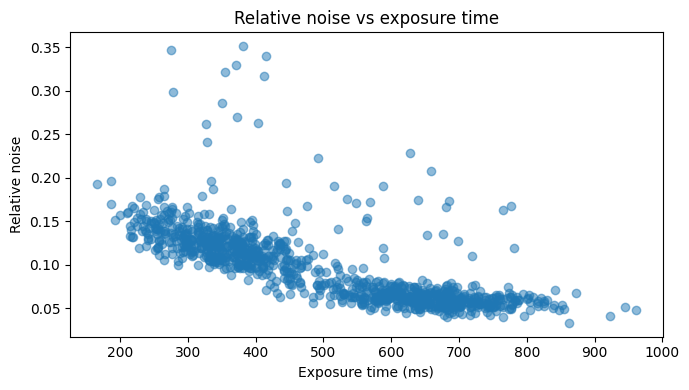

Saved: ..\figures\01_dataset_generation\cnr_vs_abs_porosity_error.png


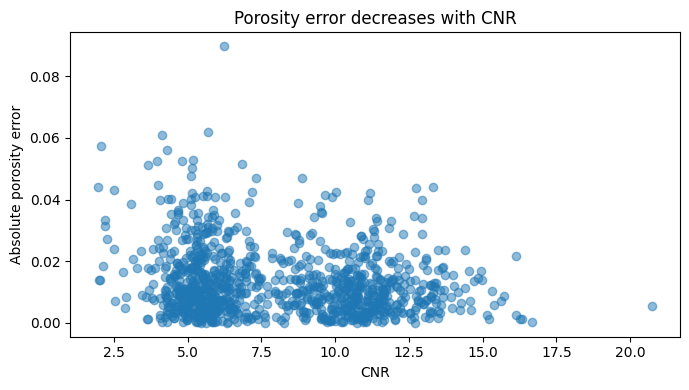

Saved: ..\figures\01_dataset_generation\detectability_vs_abs_porosity_error.png


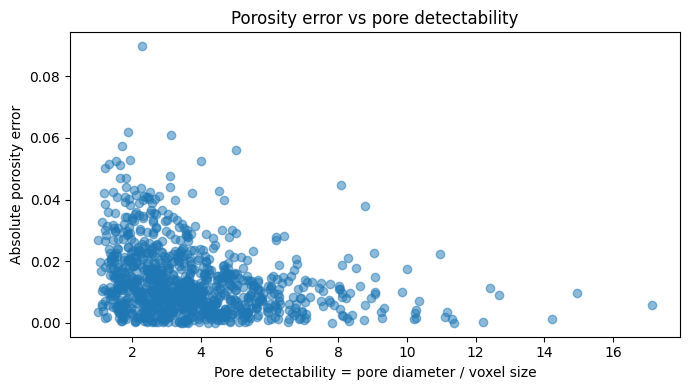

C:\Users\Peter\AppData\Local\Temp\ipykernel_20708\1113811802.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_a, data_b], labels=["A_standard", "B_optimized"])


Saved: ..\figures\01_dataset_generation\quality_score_by_protocol.png


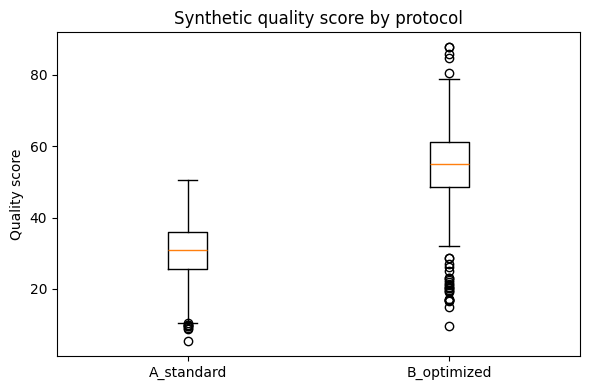

Saved: ..\figures\01_dataset_generation\temporal_snr_drift.png


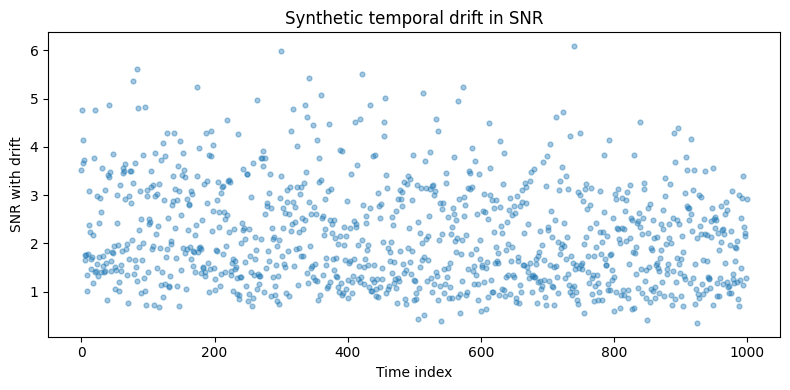

In [14]:
def save_current_figure(filename):
    output_path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.show()


# 1. True porosity distribution
plt.figure(figsize=(7, 4))
plt.hist(df["true_porosity"], bins=30)
plt.xlabel("True porosity")
plt.ylabel("Count")
plt.title("Distribution of true porosity")
save_current_figure("true_porosity_distribution.png")


# 2. Noise vs exposure
plt.figure(figsize=(7, 4))
plt.scatter(df["exposure_ms"], df["relative_noise_drifted"], alpha=0.5)
plt.xlabel("Exposure time (ms)")
plt.ylabel("Relative noise")
plt.title("Relative noise vs exposure time")
save_current_figure("relative_noise_vs_exposure.png")


# 3. CNR vs absolute porosity error
plt.figure(figsize=(7, 4))
plt.scatter(df["cnr_drifted"], df["abs_porosity_error"], alpha=0.5)
plt.xlabel("CNR")
plt.ylabel("Absolute porosity error")
plt.title("Porosity error decreases with CNR")
save_current_figure("cnr_vs_abs_porosity_error.png")


# 4. Detectability vs absolute porosity error
plt.figure(figsize=(7, 4))
plt.scatter(df["pore_detectability"], df["abs_porosity_error"], alpha=0.5)
plt.xlabel("Pore detectability = pore diameter / voxel size")
plt.ylabel("Absolute porosity error")
plt.title("Porosity error vs pore detectability")
save_current_figure("detectability_vs_abs_porosity_error.png")


# 5. Quality score by protocol
plt.figure(figsize=(6, 4))
data_a = df.loc[df["protocol"] == "A_standard", "quality_score"]
data_b = df.loc[df["protocol"] == "B_optimized", "quality_score"]

plt.boxplot([data_a, data_b], labels=["A_standard", "B_optimized"])
plt.ylabel("Quality score")
plt.title("Synthetic quality score by protocol")
save_current_figure("quality_score_by_protocol.png")


# 6. Temporal SNR drift
plt.figure(figsize=(8, 4))
plt.scatter(df["time_index"], df["snr_drifted"], alpha=0.4, s=12)
plt.xlabel("Time index")
plt.ylabel("SNR with drift")
plt.title("Synthetic temporal drift in SNR")
save_current_figure("temporal_snr_drift.png")